In [1]:
%load_ext autoreload
%autoreload 2

### Setup

In [2]:
import os, sys
sys.path.append(os.path.dirname(os.getcwd())) # Add the parent directory to sys.path
sys.path.append('/Users/dhei/ai2/new-evals/olmo-repos/olmo/scripts') # Add the parent directory to sys.path
sys.path.append('/Users/dhei/ai2/new-evals/olmo-repos/olmo/scripts/scaling')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils import DATA_DIR, ROOT_DIR

import ladder
plt.close()

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning) # supress function fitting warnings

In [3]:
# from download.weka import pull_predictions_from_weka
# pull_predictions_from_weka("consistent_ranking_final")

# from download.hf import pull_predictions_from_hf
# pull_predictions_from_hf("davidheineman/consistent-ranking-evals-metrics", "consistent_ranking_final")

from download.weka import download_from_weka
bucket_name = 'oe-eval-default'
file_key = f'davidh/metaeval/analysis/data/consistent_ranking_final_metrics.csv'
local_path = f'{DATA_DIR}/consistent_ranking_final_metrics.csv'
download_from_weka(bucket_name, file_key, local_path)

File already exists and matches size: /Users/dhei/ai2/new-evals/analysis/data/consistent_ranking_final_metrics.csv


In [4]:
df = pd.read_csv(f'{DATA_DIR}/consistent_ranking_final_metrics.csv')
print(f'Loaded {len(df):,} model evaluations')

# Preprocess the df into a usuable format
df = df.drop(columns=["Unnamed: 0"])
df["metrics"] = df["metrics"].apply(eval)
metrics_df = df["metrics"].apply(pd.Series)
df = pd.concat([df.drop(columns=["metrics"]), metrics_df], axis=1)
df = df.loc[:, ~df.columns.duplicated()]

df['size'] = df['model']
df['model'] = df['group'] + '-' + df['model'] + '-' + df['chinchilla']

# Compute MMLU macro-average
group_cols = ['group', 'model', 'chinchilla', 'step', 'seed']
agg_cols = [col for col in df.columns if col not in group_cols and col != 'task']
mmlu_rows = df[df['task'].str.contains("MMLU", case=False)]
numeric_cols = mmlu_rows[agg_cols].select_dtypes(include=['number']).columns.tolist()
aggregated = mmlu_rows.groupby(group_cols, as_index=False)[numeric_cols].mean()
aggregated['task'] = 'mmlu'
df = df[~df['task'].str.contains("MMLU", case=False)]
df = pd.concat([df, aggregated], ignore_index=True)

# Remove bad mixes
BAD_MIXES = ["DCLM-baseline-25p", "DCLM-baseline-50p", "DCLM-baseline-75p"]
for bad_mix in BAD_MIXES:
    df = df[df["group"] != bad_mix]

Loaded 361,020 model evaluations


In [5]:
MIXES = df['group'].unique()
SIZES = df['size'].unique()
MULT = df['chinchilla'].unique()

MODELS = df['model'].unique()
TASKS = df['task'].unique()

METRICS_RC= [
    "primary_metric", "correct_prob", "correct_prob_per_token", "correct_prob_per_char", "margin", "margin_per_token", "margin_per_char", "total_prob", "total_prob_per_token", "total_prob_per_char", "uncond_correct_prob", "uncond_correct_prob_per_token", "uncond_correct_prob_per_char", "norm_correct_prob", "norm_correct_prob_per_token", "norm_correct_prob_per_char"
]

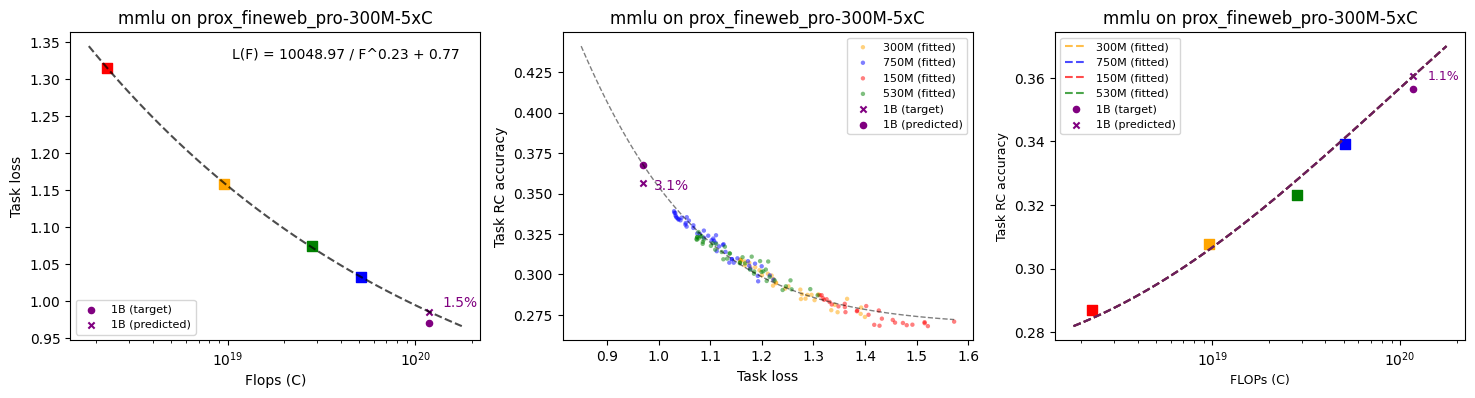

In [6]:
import matplotlib.pyplot as plt
from ladder_ian import run_ladder

fig, axes = plt.subplots(1, 3, figsize=(6*3, 4), squeeze=False)

task_name = "mmlu"
example_models = [m for m in MODELS if 'prox_fineweb_pro' in m]

train_models, eval_models = [m for m in example_models if '1B' not in m], [m for m in example_models if '1B' in m]
_, _, rel_error = run_ladder(
    df,
    task_name,
    train_models=train_models,
    eval_models=eval_models,
    x_metric='correct_logit_per_byte',
    y_metric='acc_per_char',
    use_flops=True,
    axes=axes[0],
)

for ax in axes[0]:
    ax.set_title(f'{task_name} on {example_models[0]}')

Fitting model ladder predictions: 100%|██████████| 10/10 [00:00<00:00, 11.91it/s]


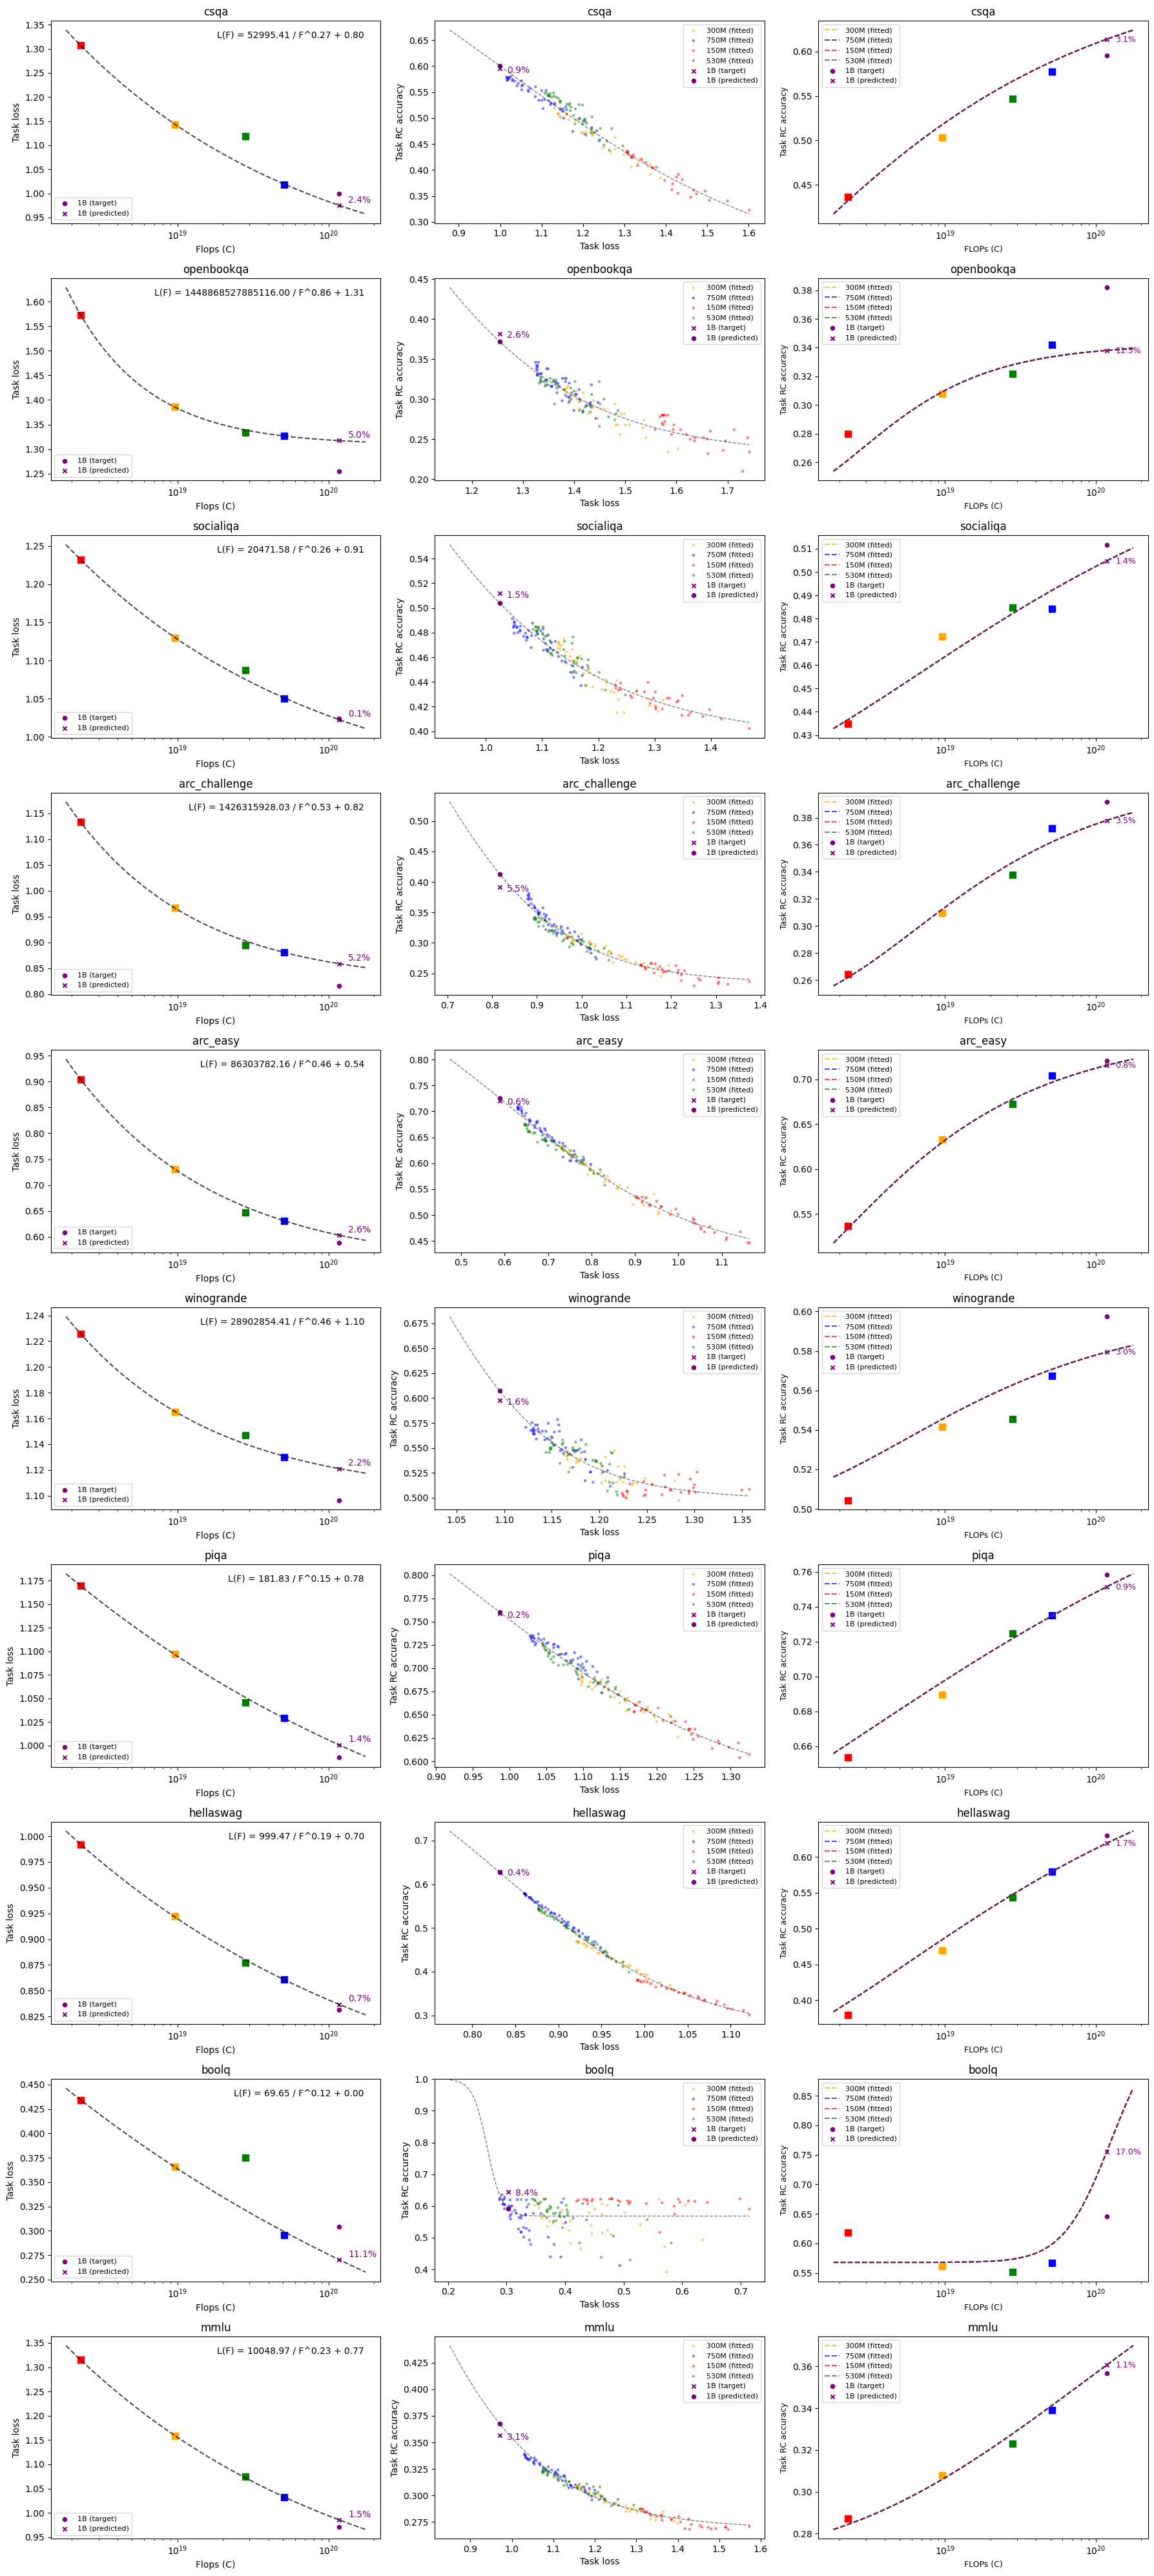

In [7]:
from tqdm import tqdm

num_rows, num_cols = len(TASKS), 3
fig, axes = plt.subplots(num_rows, num_cols, figsize=(6 * num_cols, 4 * num_rows), squeeze=False)

fitting_results = pd.DataFrame(index=[], columns=TASKS)

for i, task in tqdm(enumerate(TASKS), desc='Fitting model ladder predictions', total=len(TASKS)):
    train_models, eval_models = [m for m in example_models if '1B' not in m], [m for m in example_models if '1B' in m]
    _, _, _ = run_ladder(
        df,
        task_name=task,
        train_models=train_models,
        eval_models=eval_models,
        x_metric='correct_logit_per_byte',
        y_metric='acc_per_char',
        use_flops=True,
        axes=axes[i],
    )

fig.tight_layout()

### Fitting results on all models

In [8]:
from tqdm import tqdm

def fit_all_mixes(df, mixes, x_metric='correct_logit_per_byte', y_metric='acc_per_char', include_750m=True, quiet=True):
    fitting_results_step_1 = pd.DataFrame(index=[], columns=TASKS)
    fitting_results_step_2 = pd.DataFrame(index=[], columns=TASKS)
    fitting_results_stacked = pd.DataFrame(index=[], columns=TASKS)
    step_1_y_preds = pd.DataFrame(index=[], columns=TASKS)
    step_2_y_preds = pd.DataFrame(index=[], columns=TASKS)
    stacked_y_preds = pd.DataFrame(index=[], columns=TASKS)

    for mix in tqdm(mixes, desc='Fitting model ladder predictions', total=len(mixes)):
        models = [model for model in MODELS if '-'.join(model.split('-')[:-2]) == mix]

        for i, task in enumerate(TASKS):
            if include_750m:
                train_models, eval_models = [m for m in models if '1B' not in m and '750M' not in m], [m for m in models if '1B' in m]
            else:
                train_models, eval_models = [m for m in models if '1B' not in m], [m for m in models if '1B' in m]
            try:
                (rel_error_step_1, rel_error_step_2, rel_error_step_stacked), (step_1_y_pred, step_2_y_pred, stacked_y_pred) = run_ladder(
                    df,
                    task_name=task,
                    train_models=train_models,
                    eval_models=eval_models,
                    x_metric=x_metric,
                    y_metric=y_metric,
                    use_flops=True,
                    return_preds=True
                )
            except Exception as e:
                rel_error_step_1, rel_error_step_2, stacked_y_pred = float('inf'), float('inf'), float('inf')
                print(f'Failed on task={task}, mix={mix}')

            fitting_results_step_1.loc[mix, task] = rel_error_step_1
            fitting_results_step_2.loc[mix, task] = rel_error_step_2
            fitting_results_stacked.loc[mix, task] = rel_error_step_stacked
            step_1_y_preds.loc[mix, task] = step_1_y_pred
            step_2_y_preds.loc[mix, task] = step_2_y_pred
            stacked_y_preds.loc[mix, task] = stacked_y_pred

    fitting_results_step_1['avg'] = fitting_results_step_1.mean(axis=1)
    fitting_results_step_1 = fitting_results_step_1.abs()
    fitting_results_step_1 = fitting_results_step_1.sort_values(by='avg', ascending=False)

    fitting_results_step_2['avg'] = fitting_results_step_2.mean(axis=1)
    fitting_results_step_2 = fitting_results_step_2.abs()
    fitting_results_step_2 = fitting_results_step_2.sort_values(by='avg', ascending=False)

    fitting_results_stacked['avg'] = fitting_results_stacked.mean(axis=1)
    fitting_results_stacked = fitting_results_stacked.abs()
    fitting_results_stacked = fitting_results_stacked.sort_values(by='avg', ascending=False)

    step_1_y_preds['avg'] = step_1_y_preds.mean(axis=1)
    step_1_y_preds = step_1_y_preds.sort_values(by='avg', ascending=False)

    step_2_y_preds['avg'] = step_2_y_preds.mean(axis=1)
    step_2_y_preds = step_2_y_preds.sort_values(by='avg', ascending=False)

    stacked_y_preds['avg'] = stacked_y_preds.mean(axis=1)
    stacked_y_preds = stacked_y_preds.sort_values(by='avg', ascending=False)

    if not quiet:
        print(f'Relative unsigned error for prediticting 1B-5xC (stacked):')
        fitting_results_step_stacked_display = fitting_results_stacked.map(lambda x: f'{round(x*100, 1)}%')
        display(fitting_results_step_stacked_display)
        
        print('Predicted performance for 1B-5xC on all mixes:')
        stacked_y_preds_display = stacked_y_preds.map(lambda x: f'{round(x * 100, 1)}%')
        display(stacked_y_preds_display)


    return (fitting_results_step_1, fitting_results_step_2, fitting_results_stacked), (step_1_y_preds, step_2_y_preds, stacked_y_preds)

In [22]:
(_, _, stacked_rel_error), (_, _, stacked_y_preds) = fit_all_mixes(
    df,
    MIXES,
    x_metric="correct_logit_per_byte",
    y_metric="acc_per_char",
    include_750m=True,
    quiet=False
)

Fitting model ladder predictions: 100%|██████████| 26/26 [00:13<00:00,  1.98it/s]

Relative unsigned error for prediticting 1B-5xC (stacked):


,csqa,openbookqa,socialiqa,arc_challenge,arc_easy,winogrande,piqa,hellaswag,boolq,mmlu,avg
no_math_no_code,23.7%,21.4%,8.8%,23.3%,22.2%,10.8%,8.2%,0.7%,9.8%,12.5%,14.0%
no_reddit,22.8%,21.5%,10.3%,24.6%,23.9%,3.6%,2.2%,3.5%,14.8%,12.0%,13.9%
baseline,13.4%,27.0%,8.3%,21.0%,18.0%,4.9%,2.5%,0.5%,17.0%,13.9%,12.6%
dolma-v1-6-and-sources-baseline,28.1%,28.8%,11.9%,16.7%,17.4%,11.1%,2.7%,0.1%,23.0%,10.8%,12.3%
dolma17,13.7%,19.6%,9.5%,17.8%,22.3%,6.9%,4.8%,4.2%,14.4%,4.4%,11.8%
no_code,16.3%,20.5%,6.8%,21.0%,23.1%,4.5%,3.0%,1.4%,14.5%,9.0%,10.8%
falcon_and_cc_eli5_oh_top10p,1.8%,14.4%,14.5%,9.5%,4.1%,1.6%,1.0%,1.4%,21.0%,6.0%,7.6%
dolma17-75p-DCLM-baseline-25p,19.7%,11.3%,1.0%,10.7%,6.8%,4.1%,1.0%,3.3%,11.5%,2.3%,7.2%
falcon_and_cc,1.5%,5.8%,2.6%,7.3%,2.8%,5.1%,0.3%,0.9%,53.5%,5.6%,6.7%
DCLM-baseline,5.5%,14.3%,1.4%,10.0%,5.2%,9.1%,0.9%,0.9%,34.3%,5.9%,4.3%


Predicted performance for 1B-5xC on all mixes:


,csqa,openbookqa,socialiqa,arc_challenge,arc_easy,winogrande,piqa,hellaswag,boolq,mmlu,avg
falcon_and_cc_eli5_oh_top10p,64.5%,46.2%,57.9%,44.7%,75.8%,62.9%,75.5%,65.0%,79.0%,37.6%,60.9%
DCLM-baseline,61.2%,33.1%,51.4%,40.6%,74.3%,67.8%,74.5%,63.7%,85.9%,37.3%,59.0%
dclm_ft7percentile_fw2,64.7%,40.8%,54.5%,45.3%,78.3%,59.7%,75.0%,59.9%,64.5%,41.0%,58.4%
falcon_and_cc,59.8%,36.2%,50.0%,36.6%,68.5%,58.6%,75.2%,62.8%,97.4%,34.5%,58.0%
falcon_and_cc_og_eli5_oh_top10p,65.4%,40.6%,53.0%,42.8%,74.7%,59.4%,73.2%,64.3%,66.5%,38.7%,57.9%
falcon_and_cc_eli5_oh_top20p,64.9%,38.1%,53.5%,42.0%,70.4%,61.1%,75.6%,62.4%,64.2%,35.7%,56.8%
pos_eli5_oh_neg_dclm_refinedweb_steps_2000_lr3e4_top10p,63.5%,36.8%,49.9%,45.7%,76.0%,61.7%,73.7%,62.6%,64.5%,32.2%,56.7%
pos_eli5_oh_neg_dclm_refinedweb_steps_2000_lr3e4_top20p,66.9%,36.3%,51.9%,44.0%,75.1%,59.0%,75.2%,64.2%,58.7%,31.4%,56.3%
fineweb_edu_dedup,61.8%,40.3%,50.5%,42.7%,74.0%,55.8%,74.3%,60.3%,62.7%,39.5%,56.2%
dclm_ft7percentile_fw3,60.5%,35.5%,49.7%,49.5%,78.1%,54.9%,72.1%,56.0%,60.0%,43.3%,56.0%


In [23]:
(_, _, stacked_rel_error_no_750m), (_, _, stacked_y_preds_no_750m) = fit_all_mixes(
    df,
    MIXES,
    x_metric="correct_logit_per_byte",
    y_metric="acc_per_char",
    include_750m=False,
    quiet=True
)

Fitting model ladder predictions: 100%|██████████| 26/26 [00:15<00:00,  1.65it/s]


In [24]:
# Display results with and without the 750M model
average_rel_error_df = pd.DataFrame({"avg. rel error": stacked_rel_error.mean(axis=0)}).reset_index()
average_rel_error_df.columns = ['metric', 'avg. rel error']

average_rel_error_no_750m_df = pd.DataFrame({"avg. rel error (no 750M)": stacked_rel_error_no_750m.mean(axis=0)}).reset_index()
average_rel_error_no_750m_df.columns = ['metric', 'avg. rel error (no 750M)']

merged_rel_error_df = pd.merge(
    average_rel_error_df,
    average_rel_error_no_750m_df,
    on='metric',
    how='outer'
)

merged_rel_error_df = merged_rel_error_df.sort_values(by='avg. rel error')
merged_rel_error_df['avg. rel error'] = merged_rel_error_df['avg. rel error'].map(lambda x: f'{round(x * 100, 1)}%' if isinstance(x, float) else str(x))
merged_rel_error_df['avg. rel error (no 750M)'] = merged_rel_error_df['avg. rel error (no 750M)'].map(lambda x: f'{round(x * 100, 1)}%' if isinstance(x, float) else str(x))

# Move avg error to the bottom
avg_error_row = merged_rel_error_df[merged_rel_error_df['metric'] == 'avg']
merged_rel_error_df = merged_rel_error_df[merged_rel_error_df['metric'] != 'avg']
merged_rel_error_df = pd.concat([merged_rel_error_df, avg_error_row], ignore_index=True)

print(f'Relative error predciting acc_per_char using bpb as an intermediate feature, averaged across {len(MIXES)} data mixes:')
merged_rel_error_df.reset_index(drop=True)

Relative error predciting acc_per_char using bpb as an intermediate feature, averaged across 26 data mixes:


,metric,avg. rel error,avg. rel error (no 750M)
0,piqa,1.8%,1.6%
1,hellaswag,1.8%,1.8%
2,winogrande,4.9%,3.5%
3,socialiqa,5.1%,4.1%
4,mmlu,6.2%,5.4%
5,arc_easy,7.0%,5.7%
6,csqa,7.9%,6.2%
7,arc_challenge,8.2%,7.3%
8,openbookqa,11.4%,8.9%
9,boolq,11.8%,8.6%


### Fit ladder for all metrics

In [12]:
all_predictions = []

for metric in tqdm(METRICS_RC, desc='Fitting ladder to predict all metrics'):
    if 'uncond_' in metric: continue

    for include_750m in [True, False]:
        (step_1_rel_error, step_2_rel_error, stacked_rel_error), (step_1_y_preds, step_2_y_preds, stacked_y_preds) = fit_all_mixes(
            df,
            MIXES,
            x_metric="correct_logit_per_byte",
            y_metric=metric,
            include_750m=include_750m,
        )

        all_predictions += [(
            x, 
            y, 
            metric, 
            include_750m, # include 750m
            step_1_y_preds.loc[y, x], 
            step_2_y_preds.loc[y, x], 
            stacked_y_preds.loc[y, x], 
            step_1_rel_error.loc[y, x],
            step_2_rel_error.loc[y, x],
            stacked_rel_error.loc[y, x]
        ) for x in stacked_y_preds.columns for y in stacked_y_preds.index]

Fitting ladder to predict all metrics: 100%|██████████| 16/16 [06:34<00:00, 24.64s/it]


### Export predictions

In [17]:
results = pd.DataFrame(all_predictions, columns=['task', 'mix', 'metric', 'include_750m', 'step_1_pred', 'step_2_pred', 'stacked_pred', 'rel_error_step_1', 'rel_error_step_2', 'rel_error_stacked'])

display(results)

,task,mix,metric,include_750m,step_1_pred,step_2_pred,stacked_pred,rel_error_step_1,rel_error_step_2,rel_error_stacked
0,csqa,DCLM-baseline,primary_metric,True,0.958915,0.633275,0.588978,0.069868,0.026864,0.044964
1,csqa,dclm_ft7percentile_fw2,primary_metric,True,0.913438,0.631186,0.629608,0.005172,0.035857,0.033269
2,csqa,falcon_and_cc_og_eli5_oh_top10p,primary_metric,True,0.919974,0.633703,0.624241,0.014194,0.039989,0.024460
3,csqa,falcon_and_cc,primary_metric,True,0.992975,0.589438,0.575352,0.019969,0.003770,0.020216
4,csqa,falcon_and_cc_eli5_oh_top10p,primary_metric,True,0.939173,0.623836,0.626372,0.004089,0.000925,0.004994
...,...,...,...,...,...,...,...,...,...,...
7431,avg,no_code,norm_correct_prob_per_char,False,1.250688,0.347222,0.347099,0.098174,0.043394,0.043572
7432,avg,dolma17,norm_correct_prob_per_char,False,1.281877,0.346788,0.346245,0.089019,0.033710,0.035467
7433,avg,no_reddit,norm_correct_prob_per_char,False,1.238709,0.349698,0.345601,0.012121,0.023753,0.037924
7434,avg,baseline,norm_correct_prob_per_char,False,1.326829,0.345317,0.344952,0.078084,0.045257,0.046086


In [18]:
results.to_csv(f'{DATA_DIR}/cheap_decisions_stacked_rc_pred.csv')